# 05 — scRNA-seq with Seurat

**Run on: x86** — Requires Cell Ranger output. Run `scripts/python/download_cellranger_data.py` on x86, then `scripts/python/run_cellranger.py` or `cellranger count` → filtered count matrices.

**Target:** Figs 1, 2, 3, 5 — UMAP, clusters, DE, stress correlation

## Datasets

- **Fig 1:** Sham, TAC, TAC_JQ1 non-CM
- **Fig 2:** CD45+ Sham, TAC, TAC_Brd4KO
- **Fig 3:** snRNA TAC vs TAC_Brd4KO (whole heart)
- **Fig 5:** TAC IgG vs TAC anti-IL1B

## Pipeline

1. Read10X / CreateSeuratObject
2. QC: nFeature 2000–7500, nCount < 80k, mito < 15%
3. SCTransform → Harmony → UMAP → clusters
4. FindMarkers for DE

In [1]:
# Setup (R)
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
})

set.seed(1)

# Keep notebook output compact (suppress text progress bars)
options(progressr.enable = FALSE)

out_base <- file.path("..", "output", "cellranger")

# Minimal Fig 1 scRNA reps (one each): Sham / TAC / TAC_JQ1
runs_fig1_min <- c(
  Sham = "SRR22882168",
  TAC = "SRR22882171",
  TAC_JQ1 = "SRR22882174"
)

# Helper: find a 10x matrix path for a run id
find_10x_dir <- function(run_id, base_dir = out_base) {
  candidates <- c(
    file.path(base_dir, run_id, "outs", "filtered_feature_bc_matrix"),
    file.path(base_dir, run_id, "outs", "filtered_feature_bc_matrix", ""),
    file.path(base_dir, run_id, "outs", "filtered_feature_bc_matrix.h5")
  )
  for (p in candidates) {
    if (dir.exists(p) || file.exists(p)) return(p)
  }
  NA_character_
}

paths <- vapply(unname(runs_fig1_min), find_10x_dir, character(1))
print(data.frame(condition = names(runs_fig1_min), run_id = unname(runs_fig1_min), path = paths))

if (all(is.na(paths))) {
  stop(
    "No Cell Ranger outputs found under ", out_base, "\n\n",
    "Expected: output/cellranger/<SRR>/outs/filtered_feature_bc_matrix (or .h5)\n",
    "Run (on x86): python scripts/python/run_cellranger.py --ref-scrna ... --ref-atac ...\n",
    "Then re-run this notebook."
  )
}

            condition      run_id
SRR22882168      Sham SRR22882168
SRR22882171       TAC SRR22882171
SRR22882174   TAC_JQ1 SRR22882174
                                                                           path
SRR22882168 ../output/cellranger/SRR22882168/outs/filtered_feature_bc_matrix.h5
SRR22882171 ../output/cellranger/SRR22882171/outs/filtered_feature_bc_matrix.h5
SRR22882174 ../output/cellranger/SRR22882174/outs/filtered_feature_bc_matrix.h5


In [3]:
# Load Fig 1 minimal runs (if available)

read_10x_any <- function(path) {
  if (is.na(path)) return(NULL)
  if (dir.exists(path)) {
    Read10X(data.dir = path)
  } else if (file.exists(path) && grepl("\\.h5$", path)) {
    Read10X_h5(filename = path)
  } else {
    NULL
  }
}

objs <- list()
for (cond in names(runs_fig1_min)) {
  rid <- runs_fig1_min[[cond]]
  p <- find_10x_dir(rid)
  if (is.na(p)) {
    message("Missing: ", rid, " (", cond, ")")
    next
  }
  m <- read_10x_any(p)
  if (is.null(m)) {
    message("Unreadable matrix for: ", rid, " at ", p)
    next
  }
  s <- CreateSeuratObject(counts = m, project = "Alexanian_scRNA", min.cells = 3, min.features = 200)
  s$condition <- cond
  s$run_id <- rid
  s$orig.ident <- paste0(cond, "_", rid)
  objs[[cond]] <- s
}

if (length(objs) == 0) stop("No readable matrices found.")

obj <- if (length(objs) == 1) {
  objs[[1]]
} else {
  # Merge all; add.cell.ids helps keep barcodes unique
  merge(x = objs[[1]], y = objs[-1], add.cell.ids = names(objs))
}

obj

An object of class Seurat 
21599 features across 25376 samples within 1 assay 
Active assay: RNA (21599 features, 0 variable features)
 3 layers present: counts.1, counts.2, counts.3

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


An object of class Seurat 
21599 features across 25143 samples within 1 assay 
Active assay: RNA (21599 features, 0 variable features)
 3 layers present: counts.1, counts.2, counts.3

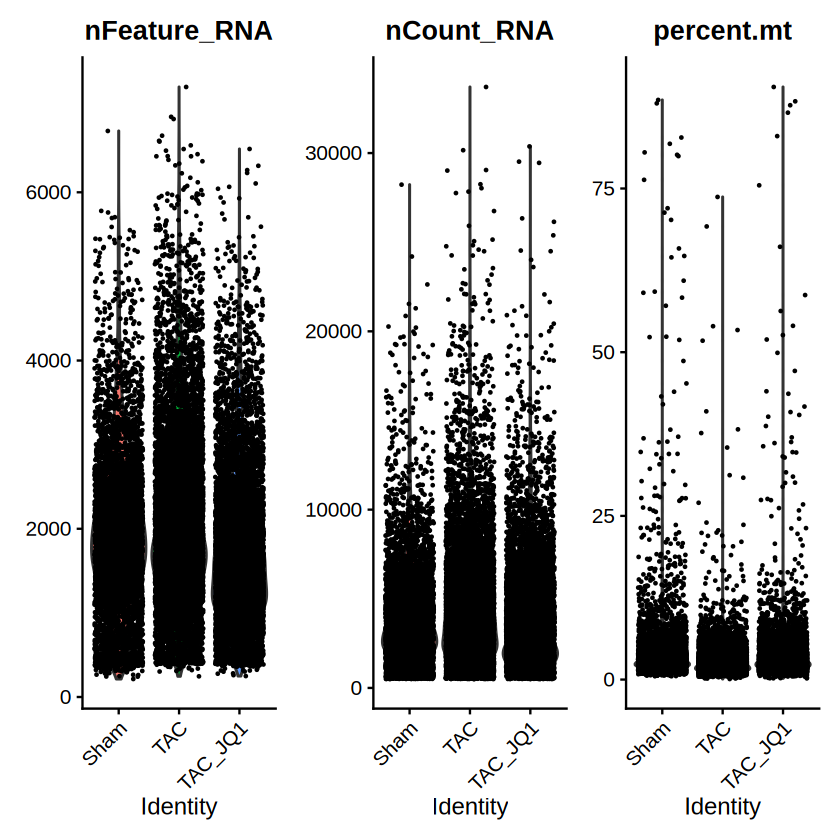

In [4]:
# QC (minimal + slide-friendly)

obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^mt-")

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), group.by = "condition", ncol = 3)

# Light-touch filters (tune if needed)
obj <- subset(obj, subset = nFeature_RNA >= 200 & nFeature_RNA <= 7500 & nCount_RNA <= 80000 & percent.mt <= 15)
obj

## Interpretation of QC violin plots

- `nFeature_RNA` and `nCount_RNA` distributions are broadly comparable across Sham, TAC, and TAC_JQ1, which supports joint downstream integration.
- A sparse high-tail of very high `nFeature_RNA`/`nCount_RNA` cells likely includes doublets or multiplets; these should be filtered or flagged before final analyses.
- Most cells have low `percent.mt`, while a small high-mito subset likely represents stressed or low-quality cells.
- Practical takeaway: current QC looks acceptable for exploratory clustering, with explicit thresholds reported for any excluded high-count/high-mito outliers.


Normalizing layer: counts.1

Normalizing layer: counts.2

Normalizing layer: counts.3

Finding variable features for layer counts.1

Finding variable features for layer counts.2

Finding variable features for layer counts.3

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 25143
Number of edges: 877319

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9285
Number of communities: 24
Elapsed time: 2 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:05:12 UMAP embedding parameters a = 0.9922 b = 1.112

10:05:12 Read 25143 rows and found 30 numeric columns

10:05:12 Using Annoy for neighbor search, n_neighbors = 30

10:05:12 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:05:13 Writing NN index file to temp file /tmp/Rtmp1HAs18/file33d30b5c4be7

10:05:13 Searching Annoy index using 1 thread, search_k = 3000

10:05:17 Annoy recall = 100%

10:05:17 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors 

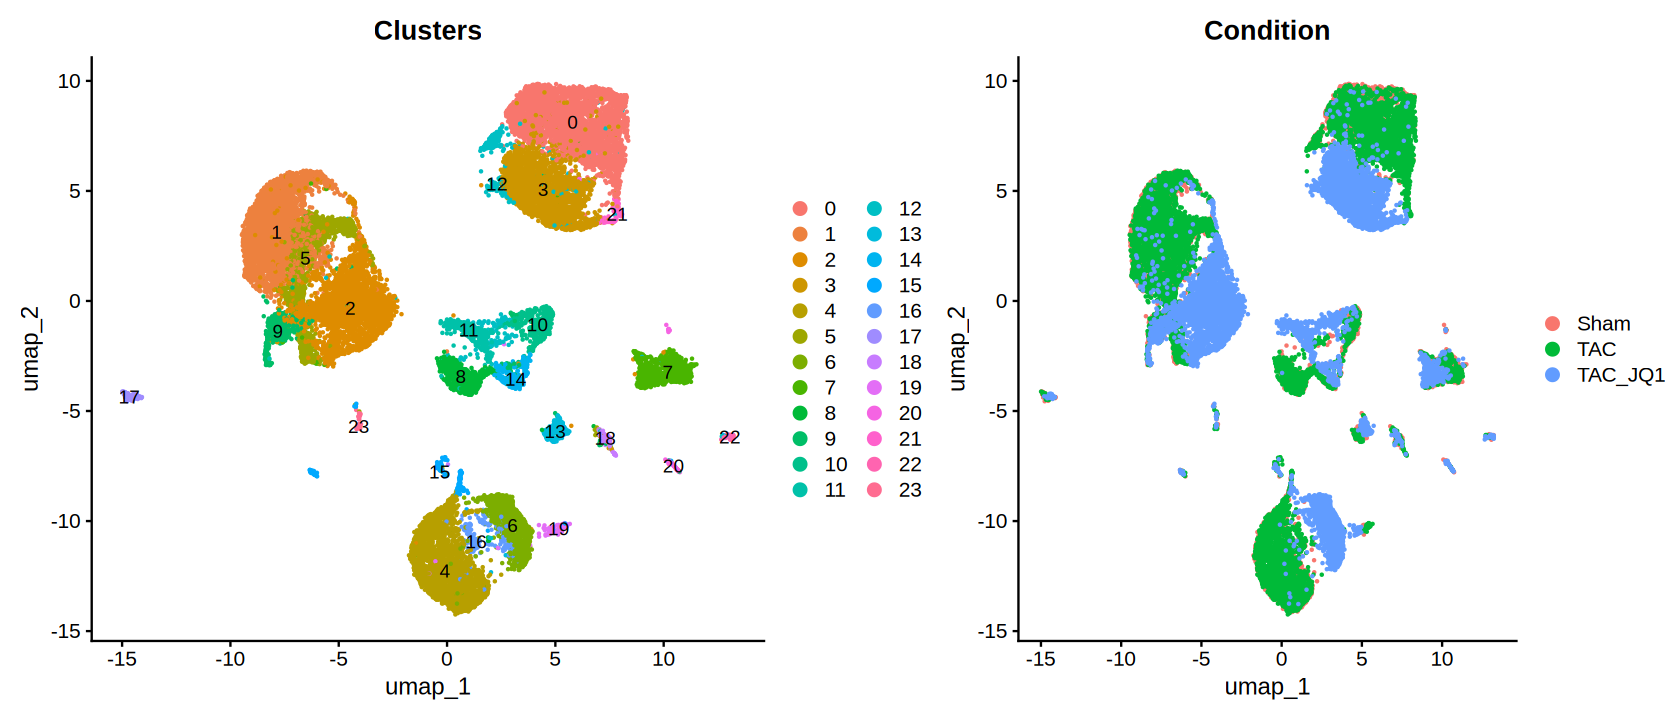

In [5]:
# Normalize + UMAP + clustering

obj <- NormalizeData(obj, verbose = FALSE)
obj <- FindVariableFeatures(obj, selection.method = "vst", nfeatures = 2000, verbose = FALSE)
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj, npcs = 30, verbose = FALSE)
obj <- FindNeighbors(obj, dims = 1:30, verbose = FALSE)
obj <- FindClusters(obj, resolution = 0.5, verbose = FALSE)
obj <- RunUMAP(obj, dims = 1:30, verbose = FALSE)

options(repr.plot.width = 14, repr.plot.height = 6)

p1 <- DimPlot(obj, reduction = "umap", group.by = "seurat_clusters", label = TRUE) + ggtitle("Clusters")
p2 <- DimPlot(obj, reduction = "umap", group.by = "condition") + ggtitle("Condition")

p_umap <- p1 + p2 + patchwork::plot_layout(ncol = 2, widths = c(1.35, 1.0))
p_umap


## Interpretation of UMAP and condition overlays

- The `Clusters` panel shows clear separation into multiple transcriptional communities, consistent with distinct cell states/types rather than one continuous population.
- The `Condition` panel indicates broad mixing of Sham, TAC, and TAC_JQ1 across many regions, suggesting core cell identities are shared across conditions.
- Regions with condition enrichment (more TAC or TAC_JQ1 in specific islands) are hypothesis-generating and should be tested with cluster-wise composition statistics and replicate-aware DE.
- Practical takeaway: use this map first for annotation and compositional directionality, then support claims with formal tests.


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Bnc1,0,15.68067,0.616,0.000,0,17,Bnc1
Prr15l,0,14.51298,0.358,0.000,0,17,Prr15l
Fcmr,0,13.86069,0.515,0.000,0,23,Fcmr
Igkc,0,13.63325,0.971,0.002,0,23,Igkc
Gjc3,0,13.60163,0.389,0.000,0,22,Gjc3
Iglc3,0,13.38007,0.588,0.000,0,23,Iglc3
Chst4,0,13.25193,0.547,0.000,0,17,Chst4
A730046J19Rik,0,13.20482,0.442,0.000,0,17,A730046J19Rik
Muc16,0,13.17533,0.784,0.000,0,17,Muc16


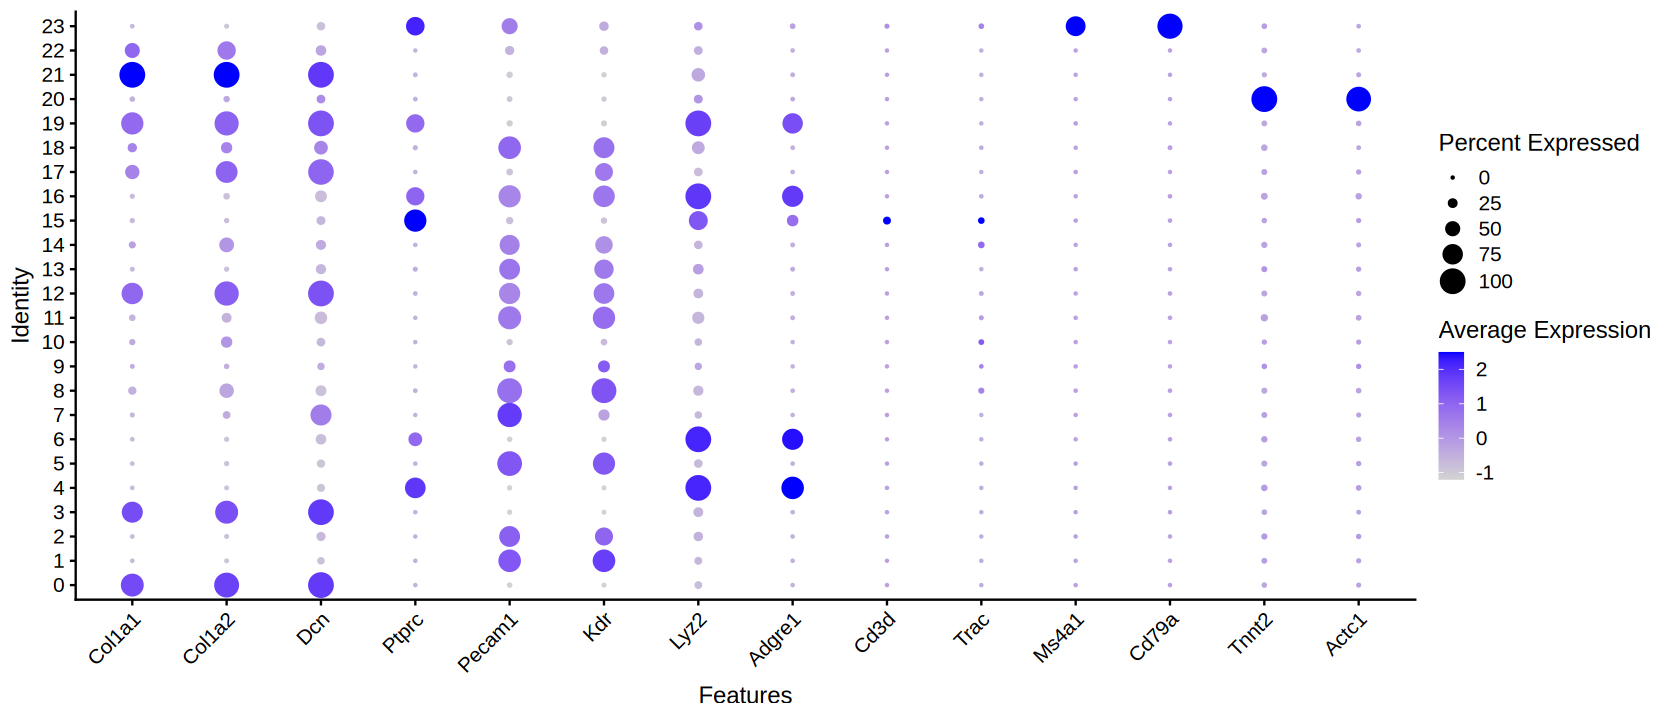

In [6]:
# Quick marker sanity check (pick a small set)

if (!requireNamespace("Seurat", quietly = TRUE)) {
  stop("Package 'Seurat' is not installed in this R environment.")
}
if (!exists("obj")) {
  stop("Seurat object 'obj' not found. Run upstream preprocessing cells first.")
}

# A few canonical markers for broad cell types in mouse heart
markers <- list(
  Fibroblast = c("Col1a1", "Col1a2", "Dcn"),
  Immune = c("Ptprc"),
  Endothelial = c("Pecam1", "Kdr"),
  Myeloid = c("Lyz2", "Adgre1"),
  Tcell = c("Cd3d", "Trac"),
  Bcell = c("Ms4a1", "Cd79a"),
  Cardiomyocyte = c("Tnnt2", "Actc1")
)

Seurat::DotPlot(obj, features = unique(unlist(markers))) + Seurat::RotatedAxis()

# Optional: identify top markers per cluster (Seurat v5-safe)
obj_de <- obj
if ("JoinLayers" %in% getNamespaceExports("SeuratObject")) {
  obj_de <- SeuratObject::JoinLayers(obj_de)
}

markers_tbl <- tryCatch(
  Seurat::FindAllMarkers(obj_de, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, verbose = FALSE),
  error = function(e) {
    warning(paste("FindAllMarkers failed:", conditionMessage(e)))
    NULL
  }
)

if (is.null(markers_tbl) || nrow(markers_tbl) == 0) {
  message("No DE genes identified with current thresholds (or DE step failed).")
} else {
  if ("avg_log2FC" %in% colnames(markers_tbl)) {
    markers_tbl$avg_log2FC <- suppressWarnings(as.numeric(as.character(markers_tbl$avg_log2FC)))
    top_markers <- markers_tbl[order(markers_tbl$p_val_adj, -markers_tbl$avg_log2FC), ]
  } else if ("avg_logFC" %in% colnames(markers_tbl)) {
    markers_tbl$avg_logFC <- suppressWarnings(as.numeric(as.character(markers_tbl$avg_logFC)))
    top_markers <- markers_tbl[order(markers_tbl$p_val_adj, -markers_tbl$avg_logFC), ]
  } else {
    warning("No logFC column found; returning unsorted table head.")
    top_markers <- markers_tbl
  }
  head(top_markers, 20)
}


## Interpretation of marker output

- The dot plot summarizes **cluster-level expression** of canonical markers: dot color reflects average expression and dot size reflects the fraction of cells expressing each gene.
- Broad annotation should be based on **marker patterns**, not single genes (for example, `Col1a1/Col1a2/Dcn` for fibroblast-like clusters, `Ptprc` for immune, `Pecam1/Kdr` for endothelial, `Tnnt2/Actc1` for cardiomyocytes).
- Condition-related differences in marker intensity are useful for hypothesis generation, but biological claims should be confirmed with replicate-aware differential testing.


## Practical tips (Cell Ranger + Seurat)

**1) Prerequisite check before running Seurat**

This notebook expects one of:

- `output/cellranger/<SRR>/outs/filtered_feature_bc_matrix/` (MEX folder), or
- `output/cellranger/<SRR>/outs/filtered_feature_bc_matrix.h5`

for each SRR used in your selected figure subset.

**2) Cell Ranger v10 CLI gotchas**

When running `cellranger count`, v10 expects explicit boolean args such as:

- `--include-introns true|false`
- `--create-bam true|false`

Use the project wrapper script so these flags are handled consistently.

**3) Minimum dataset for a quick Fig 1-style UMAP**

- Sham: `SRR22882168`
- TAC: `SRR22882171`
- TAC_JQ1: `SRR22882174`

This is enough for a minimal presentation plot.

**4) QC interpretation**

- High `nFeature_RNA` / `nCount_RNA` outliers may be doublets.
- High `percent.mt` often indicates stressed/low-quality cells.
- Keep QC thresholds simple and report them explicitly in slides.

**5) Talk-friendly wording**

"After standard Seurat QC and dimensionality reduction, we compare cluster structure and condition composition. Marker expression supports broad cell identity labels, and condition shifts are interpreted as hypothesis-generating unless supported by formal differential testing and replicate-aware statistics."

**6) Common troubleshooting**

- **No matrices found** -> Cell Ranger outputs missing or wrong path.
- **Barcode collisions after merge** -> keep `add.cell.ids` (already used).
- **Very slow runtime** -> lower PCs (e.g., 20) and skip `FindAllMarkers` on first pass.